# PR-12: Forecast-Property Visualization

Visualizes the 9 per-series forecast-output properties from `forecast_properties.py` on
samples of **synthetic** (PR-6 composite dataset) and **real** (GIFT-Eval subset) data.

**Properties computed:**
| Property | Type | Meaning |
|---|---|---|
| `fc_std` | log-float | Flatness of forecast median (low = regressed to mean) |
| `fc_range` | log-float | Peak-to-peak range of forecast median |
| `fc_ctx_corr` | float ∈ [−1,1] | Pearson corr(median, last 64 ctx steps) — AR parroting |
| `fc_ctx_corr_seasonal` | float ∈ [−1,1] | Pearson corr(median, seasonal lag) |
| `fc_iqr_mean` | float | Mean IQR = mean(q0.9 − q0.1) over horizon |
| `fc_iqr_slope` | float | Slope of IQR over horizon (positive = growing uncertainty) |
| `mase` | float ≥ 0 | Mean Absolute Scaled Error |
| `swql` | float ≥ 0 | Scaled Weighted Quantile Loss |
| `quantile_calibration_err` | float ∈ [0,1] | Mean \|empirical coverage − q\| |

**Models used:** moiraie (encoder) and moiraic (decoder). Falls back to tiny in-memory
models if checkpoint paths are not found.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import torch

# Allow import from repo root
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from experiments.mech_interp.lib import (
    generate_composite_dataset,
    load_gift_subset,
    split_dataset,
    make_batch,
    _load_module,
)
from experiments.mech_interp.block1_probing.forecast_properties import (
    QUANTILE_LEVELS,
    HORIZON,
    compute_all,
    derive_binary_labels,
)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 9})
print('Imports OK')

Imports OK


In [2]:
# ── Constants ──────────────────────────────────────────────────────────────────
PATCH_SIZE      = 16
CONTEXT_PATCHES = 32
PRED_PATCHES    = 4
SERIES_LEN      = (CONTEXT_PATCHES + PRED_PATCHES) * PATCH_SIZE  # 576
CONTEXT_END     = CONTEXT_PATCHES * PATCH_SIZE  # 512
Q               = len(QUANTILE_LEVELS)  # 9

# Sample sizes — small enough to run quickly even on CPU / tiny models
N_SYNTH = 200
N_REAL  = 200
N_SHOW  = 8   # series shown in qualitative grid

DEVICE = 'cuda:6'

# Checkpoint paths (from CLAUDE.md). Set to None to use tiny in-memory models.
CKPT = {
    'moiraie': '/srv/disk00/ctadler/uni2ts/outputs/pretrain/moiraie/gift_eval_pretrain_weighted/moiraie_training_7/HF_checkpoints/last',
    'moiraic': '/srv/disk00/ctadler/uni2ts/outputs/pretrain/moiraic/gift_eval_pretrain_weighted/moiraic_training_11/HF_checkpoints/last',
}

# Override to None to force tiny models (useful for fast smoke-testing)
# CKPT = {k: None for k in CKPT}

print(f'Series length: {SERIES_LEN}  (context {CONTEXT_END} + horizon {HORIZON})')

Series length: 576  (context 512 + horizon 64)


## 1. Load data

In [3]:
print('Generating synthetic composite dataset...')
synth_ds = generate_composite_dataset(n=N_SYNTH, seed=42)
synth_series = synth_ds['series']  # [N_SYNTH, 576]
print(f'  Synthetic: {synth_series.shape}')

print('Loading real GIFT-Eval subset (first run computes pseudo-labels — may take a moment)...')
real_ds = load_gift_subset(seed=42, n_per_dataset=N_REAL // 9 + 1)
real_series = real_ds['series'][:N_REAL]  # [N_REAL, 576]
print(f'  Real:      {real_series.shape}')

Generating synthetic composite dataset...
  Synthetic: (200, 576)
Loading real GIFT-Eval subset (first run computes pseudo-labels — may take a moment)...
  Real:      (200, 576)


## 2. Load models and extract forecasts

In [4]:
def extract_forecast_quantiles(
    module,
    series: np.ndarray,
    batch_size: int = 16,
    device: str = 'cpu',
) -> np.ndarray:
    """Run a single forward pass and return [n, Q, HORIZON] quantile forecasts.

    moiraie (encoder): output at prediction patch positions 32..35 gives valid
    forecasts because those positions are masked with mask_fill before attending.

    moiraic (decoder): output at the last context position (31) predicts all
    num_predict_token future patches in one shot (causal; no leakage from ctx).
    """
    is_moiraic = type(module).__name__.startswith('Moiraic')
    npt = module.num_predict_token
    Nq  = module.num_quantiles
    P   = module.patch_size

    all_fq = []
    module = module.to(device)
    for i in range(0, len(series), batch_size):
        chunk = series[i:i + batch_size]
        batch = make_batch(chunk, P, CONTEXT_PATCHES, PRED_PATCHES, device)
        with torch.no_grad():
            if is_moiraic:
                result = module(**batch, training_mode=False,
                                past_cache=None, return_cache=False)
            else:
                result = module(**batch, training_mode=False)

        # result: [B, n_patches, npt * Nq * P]
        B  = result.shape[0]
        rn = result.detach().cpu().float().numpy()

        if is_moiraic:
            # Last context position (31) predicts npt future patches
            pred = rn[:, CONTEXT_PATCHES - 1, :]        # [B, npt*Nq*P]
            pred = pred.reshape(B, npt, Nq, P)           # [B, npt, Q, P]
            pred = pred.transpose(0, 2, 1, 3)            # [B, Q, npt, P]
            pred = pred.reshape(B, Nq, -1)               # [B, Q, npt*P]
            # Pad / trim to HORIZON
            if pred.shape[-1] < HORIZON:
                pred = np.pad(pred, ((0,0),(0,0),(0, HORIZON - pred.shape[-1])))
            pred = pred[:, :, :HORIZON]
        else:
            # Each prediction position (32..35) predicts npt=1 patches independently
            pred = rn[:, CONTEXT_PATCHES:, :]            # [B, PRED_PATCHES, npt*Nq*P]
            pred = pred.reshape(B, PRED_PATCHES, npt, Nq, P)
            pred = pred[:, :, 0, :, :]                   # [B, PRED_PATCHES, Q, P]
            pred = pred.transpose(0, 2, 1, 3)            # [B, Q, PRED_PATCHES, P]
            pred = pred.reshape(B, Nq, -1)               # [B, Q, 64]

        all_fq.append(pred)

    return np.concatenate(all_fq, axis=0)  # [n, Q, HORIZON]


print('Loading models...')
modules = {name: _load_module(CKPT.get(name), name, device=DEVICE)
           for name in ('moiraie', 'moiraic')}
print('Models ready.')

Loading models...
  Loading moiraie from /srv/disk00/ctadler/uni2ts/outputs/pretrain/moiraie/gift_eval_pretrain_weighted/moiraie_training_7/HF_checkpoints/last (device=cuda:6)
Loading weights from local directory
  Loading moiraic from /srv/disk00/ctadler/uni2ts/outputs/pretrain/moiraic/gift_eval_pretrain_weighted/moiraic_training_11/HF_checkpoints/last (device=cuda:6)
Loading weights from local directory
Models ready.


In [5]:
# Extract forecasts — one dict per model, each value is [n, Q, 64]
forecasts = {}
for model_name, module in modules.items():
    print(f'Extracting forecasts from {model_name}...')
    forecasts[model_name] = {
        'synth': extract_forecast_quantiles(module, synth_series, device=DEVICE),
        'real':  extract_forecast_quantiles(module, real_series,  device=DEVICE),
    }
    print(f'  synth: {forecasts[model_name]["synth"].shape}')
    print(f'  real:  {forecasts[model_name]["real"].shape}')

Extracting forecasts from moiraie...
  synth: (200, 9, 64)
  real:  (200, 9, 64)
Extracting forecasts from moiraic...
  synth: (200, 9, 64)
  real:  (200, 9, 64)


In [6]:
# Compute all forecast properties for each (model, dataset) pair
#
# properties[model][dataset] is a dict[str, np.ndarray [n]]
# ctx_period defaults to 24 (dominant period placeholder; affects fc_ctx_corr_seasonal)

def compute_properties_batch(
    fq: np.ndarray,      # [n, Q, 64]
    target: np.ndarray,  # [n, 64]
    context: np.ndarray, # [n, 512]
    ctx_period: int = 24,
) -> dict[str, np.ndarray]:
    """Vectorised wrapper: computes compute_all for each series, returns dict of [n] arrays."""
    rows = [compute_all(fq[i], target[i], context[i], ctx_period)
            for i in range(len(fq))]
    keys = list(rows[0].keys())
    return {k: np.array([r[k] for r in rows]) for k in keys}


properties = {}
for model_name in modules:
    properties[model_name] = {}
    for ds_name, series in [('synth', synth_series), ('real', real_series)]:
        ctx   = series[:, :CONTEXT_END].astype(np.float64)
        tgt   = series[:, CONTEXT_END:].astype(np.float64)
        fq    = forecasts[model_name][ds_name].astype(np.float64)
        props = compute_properties_batch(fq, tgt, ctx)
        # Add binary labels derived from dataset-level medians
        labels = derive_binary_labels(props['fc_std'], props['mase'])
        props.update(labels)
        properties[model_name][ds_name] = props
        print(f'{model_name}/{ds_name}: {len(props["mase"])} series computed')

PROP_KEYS = [k for k in list(properties['moiraie']['synth'].keys())
             if k not in ('is_flat', 'is_poor')]
print('\nProperties:', PROP_KEYS)

moiraie/synth: 200 series computed
moiraie/real: 200 series computed
moiraic/synth: 200 series computed
moiraic/real: 200 series computed

Properties: ['fc_std', 'fc_range', 'fc_ctx_corr', 'fc_ctx_corr_seasonal', 'fc_iqr_mean', 'fc_iqr_slope', 'mase', 'swql', 'quantile_calibration_err']


---
## Section 1 — Sample series with model forecasts

One row per dataset type (synthetic / real), one column per example.
- **Blue** region: context (first 512 steps)
- **Red** region: true target horizon (steps 512..575)
- **Orange line**: forecast median (q=0.5)
- **Light orange band**: q0.1 – q0.9 uncertainty interval

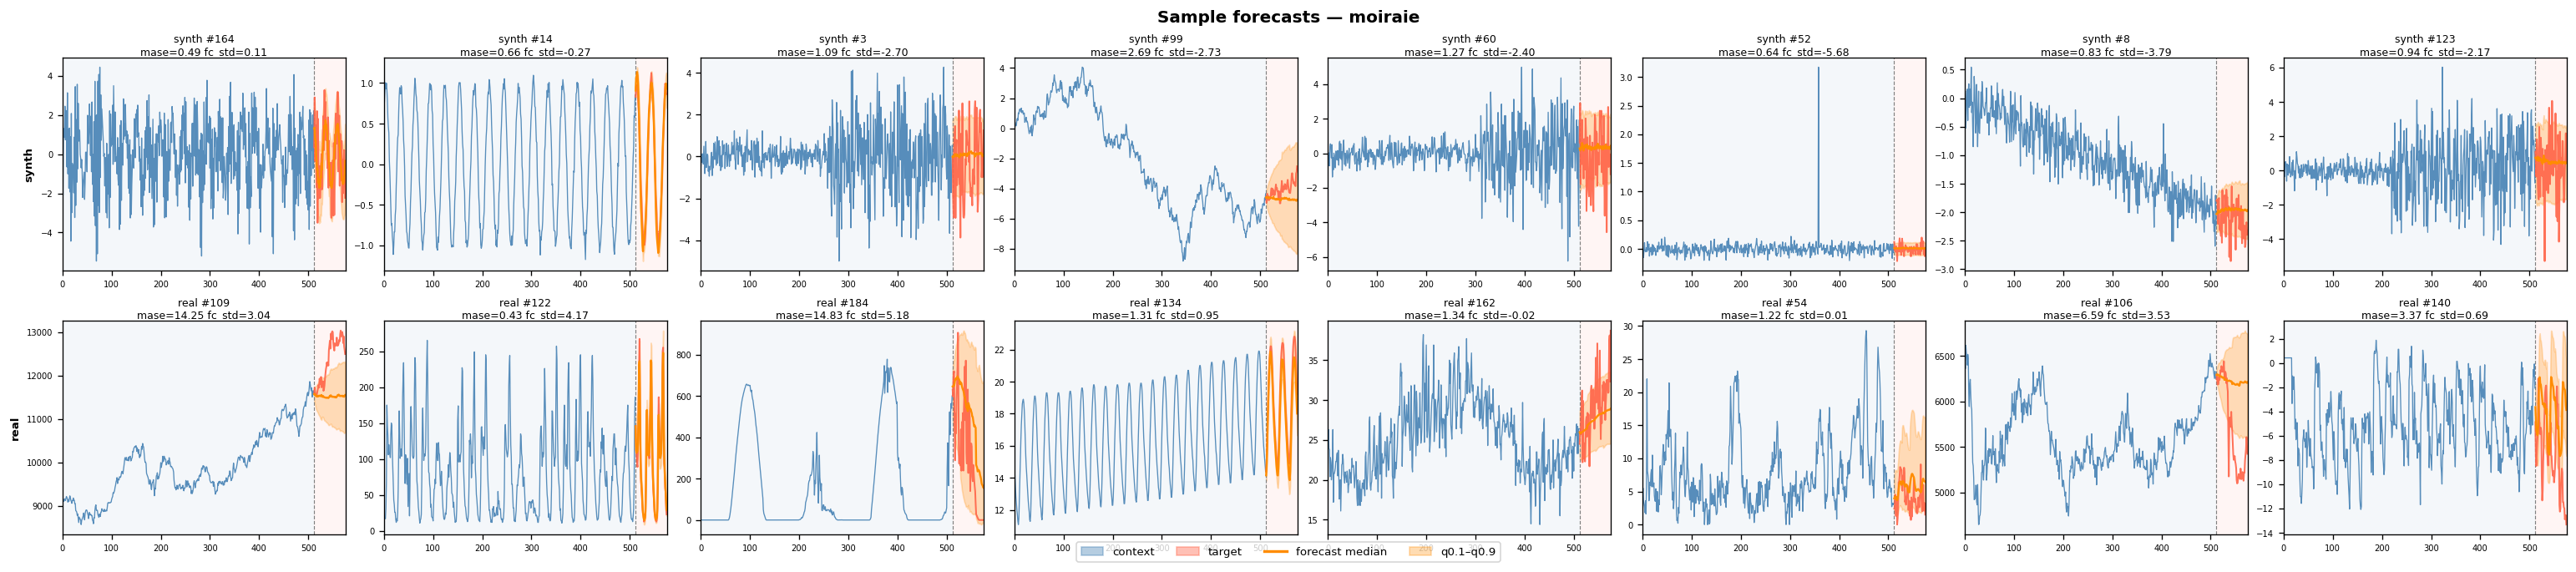

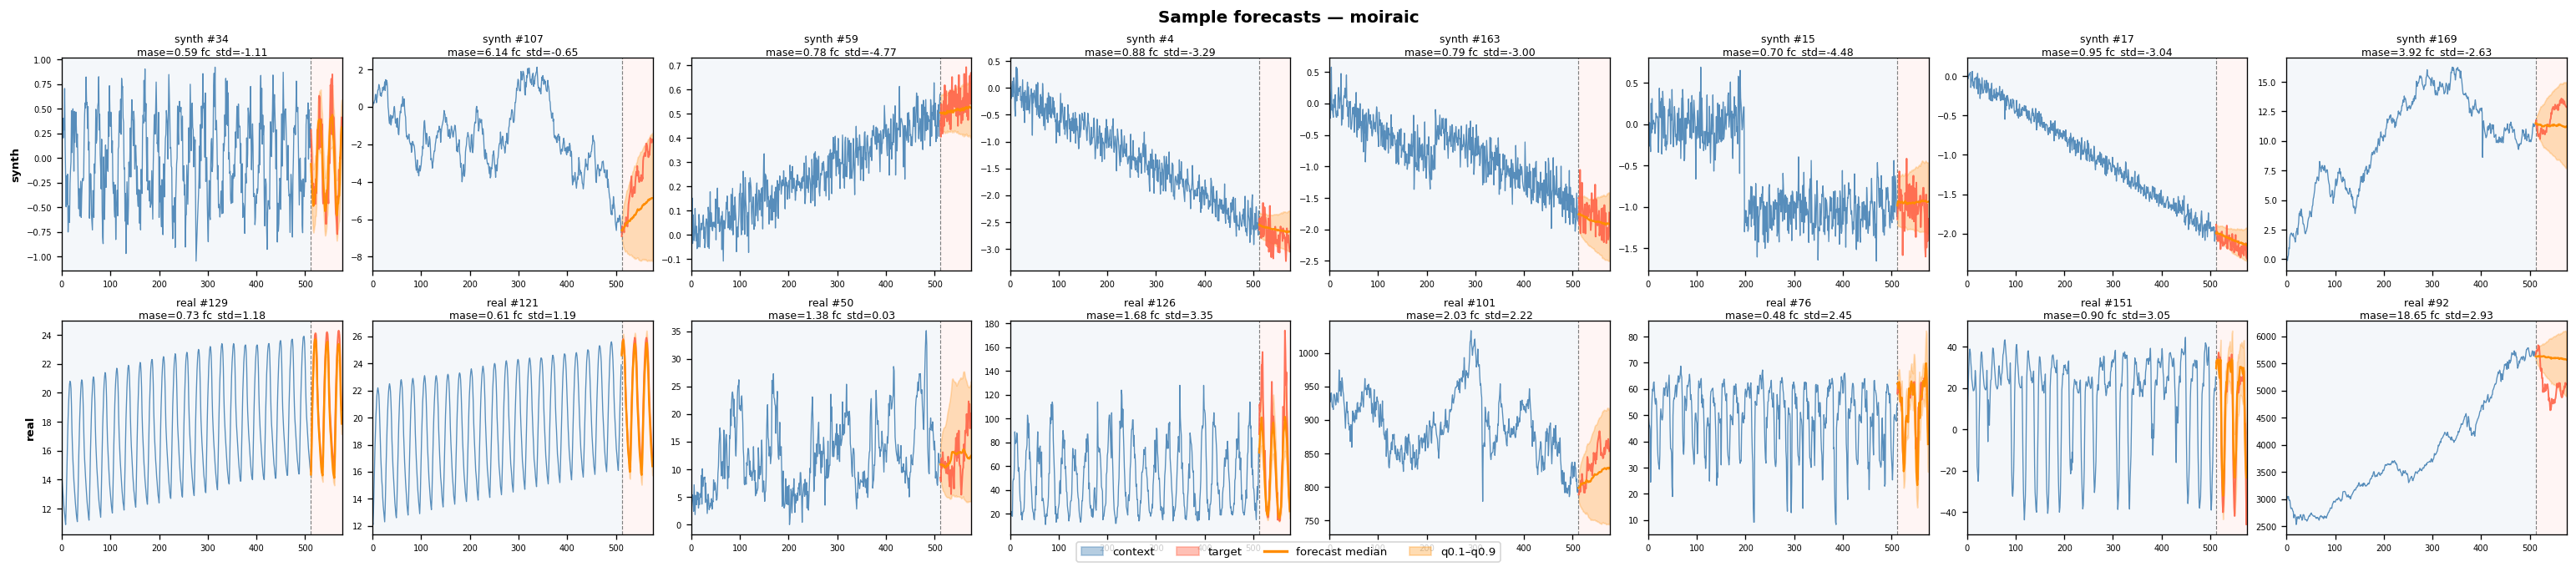

In [7]:
def plot_series_with_forecast(ax, series, fq, title=''):
    """Plot one series + forecast on ax. fq: [Q, HORIZON]."""
    t_ctx = np.arange(CONTEXT_END)
    t_hor = np.arange(CONTEXT_END, SERIES_LEN)
    ctx = series[:CONTEXT_END]
    tgt = series[CONTEXT_END:]
    median = fq[4]  # q=0.5
    q_lo   = fq[0]  # q=0.1
    q_hi   = fq[-1] # q=0.9

    ax.axvspan(0, CONTEXT_END, alpha=0.06, color='steelblue', lw=0)
    ax.axvspan(CONTEXT_END, SERIES_LEN, alpha=0.06, color='tomato', lw=0)
    ax.axvline(CONTEXT_END, color='gray', lw=0.7, ls='--')
    ax.plot(t_ctx, ctx, lw=0.8, color='steelblue', alpha=0.9)
    ax.plot(t_hor, tgt, lw=1.2, color='tomato', alpha=0.9, label='target')
    ax.fill_between(t_hor, q_lo, q_hi, alpha=0.25, color='darkorange', label='q0.1–q0.9')
    ax.plot(t_hor, median, lw=1.4, color='darkorange', label='median')
    ax.set_xlim(0, SERIES_LEN)
    ax.set_title(title, pad=2, fontsize=7.5)
    ax.tick_params(labelsize=6)


rng = np.random.default_rng(0)

for model_name in modules:
    fig, axes = plt.subplots(2, N_SHOW, figsize=(N_SHOW * 3.2, 5.5),
                              constrained_layout=True)
    fig.suptitle(f'Sample forecasts — {model_name}', fontsize=12, fontweight='bold')

    for row, (ds_name, series) in enumerate([('synth', synth_series), ('real', real_series)]):
        idxs = rng.choice(len(series), N_SHOW, replace=False)
        fq_all = forecasts[model_name][ds_name]
        props  = properties[model_name][ds_name]
        for col, idx in enumerate(idxs):
            mase_val = props['mase'][idx]
            std_val  = props['fc_std'][idx]
            plot_series_with_forecast(
                axes[row, col], series[idx], fq_all[idx],
                title=f'{ds_name} #{idx}\nmase={mase_val:.2f} fc_std={std_val:.2f}',
            )
        axes[row, 0].set_ylabel(ds_name, fontsize=8, fontweight='bold')

    legend_handles = [
        mpatches.Patch(color='steelblue', alpha=0.4, label='context'),
        mpatches.Patch(color='tomato',    alpha=0.4, label='target'),
        plt.Line2D([0],[0], color='darkorange', lw=2, label='forecast median'),
        mpatches.Patch(color='darkorange', alpha=0.3, label='q0.1–q0.9'),
    ]
    fig.legend(handles=legend_handles, loc='lower center', ncol=4,
               fontsize=8, bbox_to_anchor=(0.5, -0.02))
    plt.show()

---
## Section 2 — Property distributions: synthetic vs real

Each subplot shows the distribution of one property across all `N` series.
Blue = synthetic (ground-truth targets), coral = real (GIFT-Eval).
Both models shown side-by-side as solid vs dashed outlines.

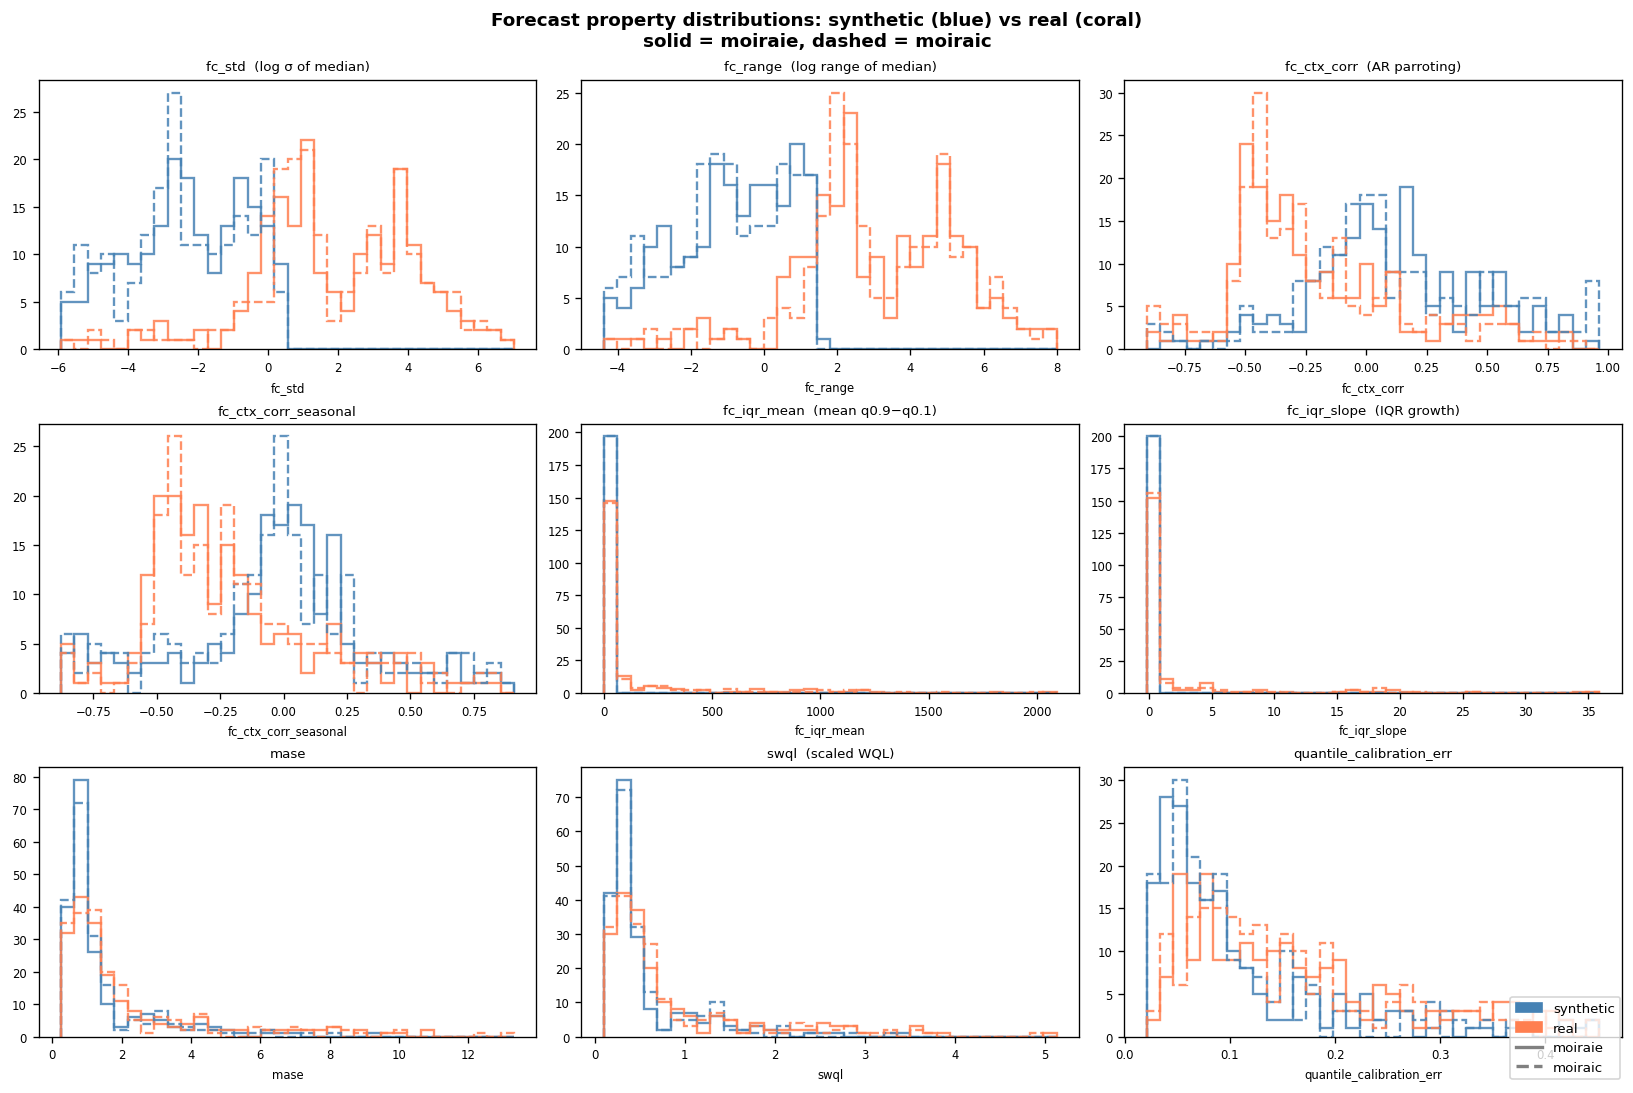

In [8]:
MODEL_STYLES = {
    'moiraie': dict(lw=1.4, ls='-',  label='moiraie (enc)'),
    'moiraic': dict(lw=1.4, ls='--', label='moiraic (dec)'),
}
DS_COLORS = {'synth': 'steelblue', 'real': 'coral'}

PROP_LABELS = {
    'fc_std':                  'fc_std  (log σ of median)',
    'fc_range':                'fc_range  (log range of median)',
    'fc_ctx_corr':             'fc_ctx_corr  (AR parroting)',
    'fc_ctx_corr_seasonal':    'fc_ctx_corr_seasonal',
    'fc_iqr_mean':             'fc_iqr_mean  (mean q0.9−q0.1)',
    'fc_iqr_slope':            'fc_iqr_slope  (IQR growth)',
    'mase':                    'mase',
    'swql':                    'swql  (scaled WQL)',
    'quantile_calibration_err':'quantile_calibration_err',
}

n_cols = 3
n_rows = (len(PROP_KEYS) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4.5, n_rows * 3.0),
                          constrained_layout=True)
fig.suptitle('Forecast property distributions: synthetic (blue) vs real (coral)\n'
             'solid = moiraie, dashed = moiraic', fontsize=11, fontweight='bold')

for ax_idx, key in enumerate(PROP_KEYS):
    ax = axes.flat[ax_idx]
    # Collect finite values across all models + datasets to set shared bins
    all_vals = [v for mn in modules
                  for ds in ('synth', 'real')
                  for v in properties[mn][ds][key] if np.isfinite(v)]
    if not all_vals:
        ax.set_visible(False)
        continue
    lo, hi = np.percentile(all_vals, [1, 99])
    bins = np.linspace(lo, hi, 35)

    for model_name, m_style in MODEL_STYLES.items():
        for ds_name, ds_color in DS_COLORS.items():
            vals = properties[model_name][ds_name][key]
            vals = vals[np.isfinite(vals)]
            ax.hist(vals, bins=bins, histtype='step',
                    color=ds_color, **m_style, alpha=0.85)

    ax.set_title(PROP_LABELS.get(key, key), fontsize=8)
    ax.tick_params(labelsize=7)
    ax.set_xlabel(key, fontsize=7)

# Turn off unused axes
for ax in axes.flat[len(PROP_KEYS):]:
    ax.set_visible(False)

# Legend
legend_handles = [
    mpatches.Patch(color='steelblue', label='synthetic'),
    mpatches.Patch(color='coral',     label='real'),
    plt.Line2D([0],[0], color='gray', ls='-',  lw=2, label='moiraie'),
    plt.Line2D([0],[0], color='gray', ls='--', lw=2, label='moiraic'),
]
fig.legend(handles=legend_handles, loc='lower right', fontsize=8,
           bbox_to_anchor=(1.0, 0.0))
plt.show()

---
## Section 3 — Binary label proportions

`is_flat` (fc_std below dataset median) and `is_poor` (mase above dataset median) are
both defined as median splits, so each should be ≈50% by construction. Deviations
between datasets or models indicate distribution shifts in the underlying properties.

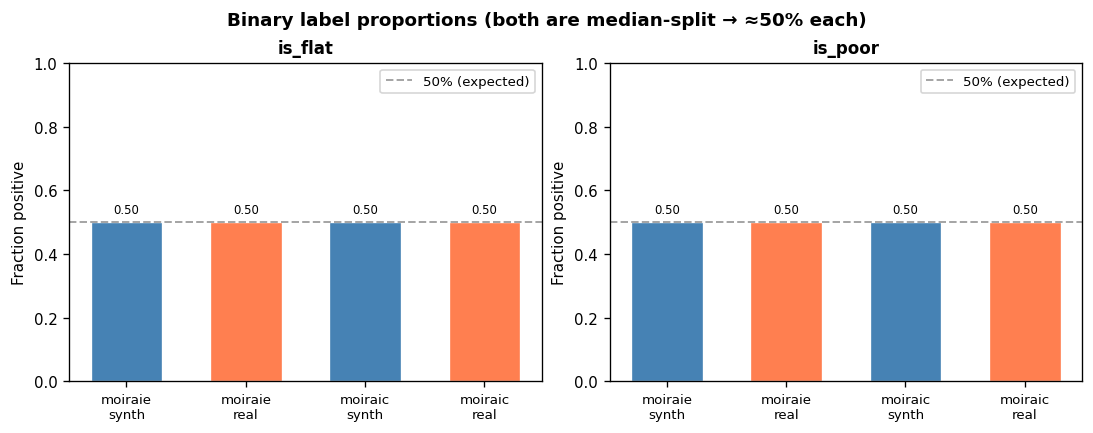

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), constrained_layout=True)
fig.suptitle('Binary label proportions (both are median-split → ≈50% each)',
             fontsize=11, fontweight='bold')

x_labels = [f'{mn}\n{ds}' for mn in ('moiraie', 'moiraic') for ds in ('synth', 'real')]
x        = np.arange(len(x_labels))
width    = 0.6

for ax_idx, label_key in enumerate(('is_flat', 'is_poor')):
    ax = axes[ax_idx]
    vals = [properties[mn][ds][label_key].mean()
            for mn in ('moiraie', 'moiraic') for ds in ('synth', 'real')]
    colors = ['steelblue', 'coral'] * 2
    bars = ax.bar(x, vals, width=width, color=colors, edgecolor='white', lw=0.8)
    ax.axhline(0.5, color='gray', ls='--', lw=1.2, alpha=0.7, label='50% (expected)')
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=8)
    ax.set_ylabel('Fraction positive', fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title(f'{label_key}', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f'{v:.2f}',
                ha='center', va='bottom', fontsize=7)

plt.show()

---
## Section 4 — Scatter pairplots of key property pairs

Three informative pairs:
1. **fc_std vs mase** — does a flat forecast correlate with higher error?
2. **fc_iqr_mean vs quantile_calibration_err** — does wider uncertainty improve calibration?
3. **fc_ctx_corr vs mase** — does parroting context reduce error?

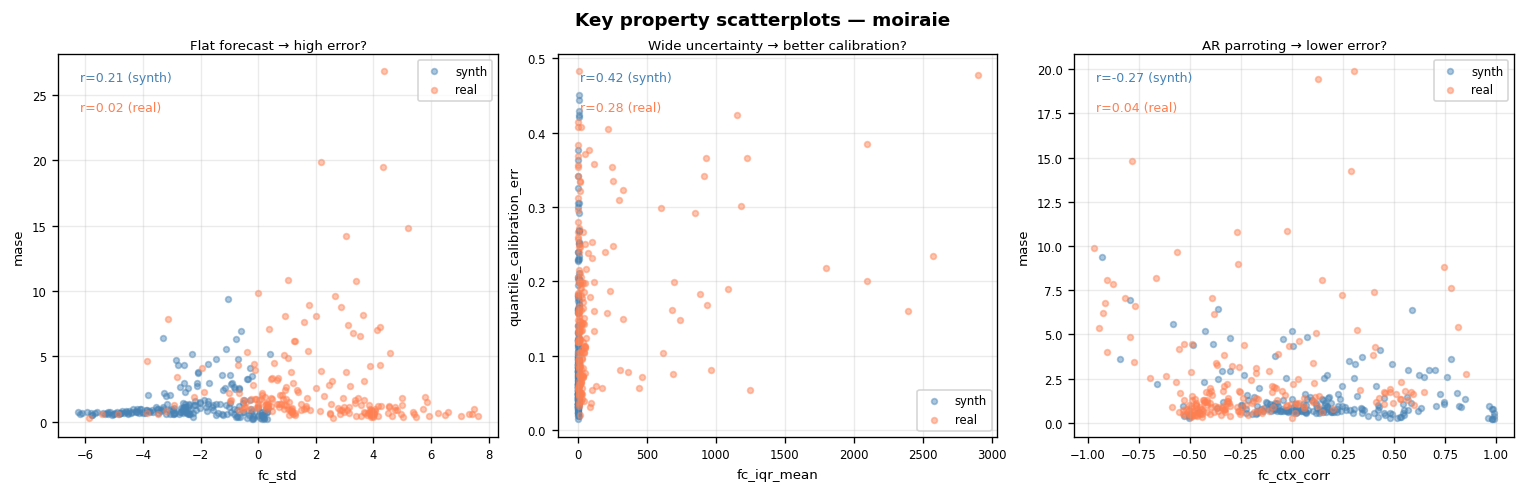

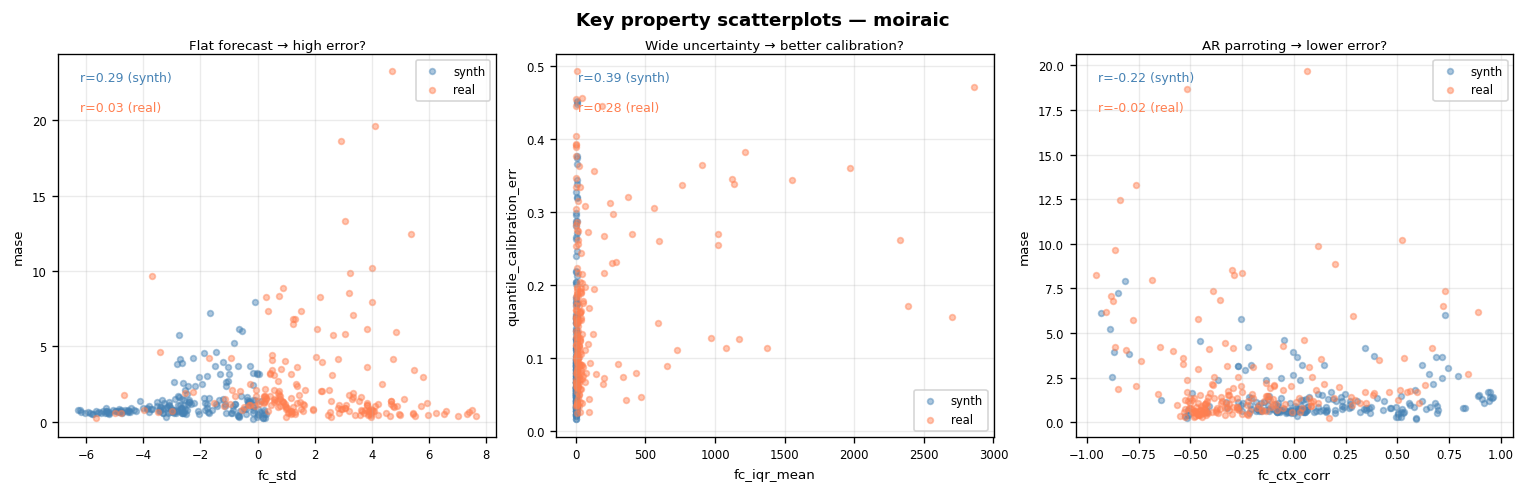

In [10]:
SCATTER_PAIRS = [
    ('fc_std',       'mase',                    'Flat forecast → high error?'),
    ('fc_iqr_mean',  'quantile_calibration_err', 'Wide uncertainty → better calibration?'),
    ('fc_ctx_corr',  'mase',                    'AR parroting → lower error?'),
]

for model_name in modules:
    fig, axes = plt.subplots(1, len(SCATTER_PAIRS),
                              figsize=(len(SCATTER_PAIRS) * 4.2, 4.0),
                              constrained_layout=True)
    fig.suptitle(f'Key property scatterplots — {model_name}', fontsize=11, fontweight='bold')

    for ax, (xk, yk, question) in zip(axes, SCATTER_PAIRS):
        for ds_name, ds_color in DS_COLORS.items():
            props = properties[model_name][ds_name]
            xv = props[xk]
            yv = props[yk]
            mask = np.isfinite(xv) & np.isfinite(yv)
            ax.scatter(xv[mask], yv[mask], s=12, alpha=0.45,
                       color=ds_color, label=ds_name, rasterized=True)
            # Pearson r annotation
            if mask.sum() > 2:
                r = float(np.corrcoef(xv[mask], yv[mask])[0, 1])
                ax.text(0.05, 0.93 if ds_name == 'synth' else 0.85,
                        f'r={r:.2f} ({ds_name})', transform=ax.transAxes,
                        fontsize=7.5, color=ds_color)

        ax.set_xlabel(xk, fontsize=8)
        ax.set_ylabel(yk, fontsize=8)
        ax.set_title(question, fontsize=8, pad=3)
        ax.legend(fontsize=7)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.25)

    plt.show()

---
## Section 5 — Inter-property correlation matrices

Pearson correlation between all 9 properties. One heatmap per (model, dataset).
High correlation → properties are redundant. Near-zero → independently informative.
NaN-to-NaN pairs are excluded.

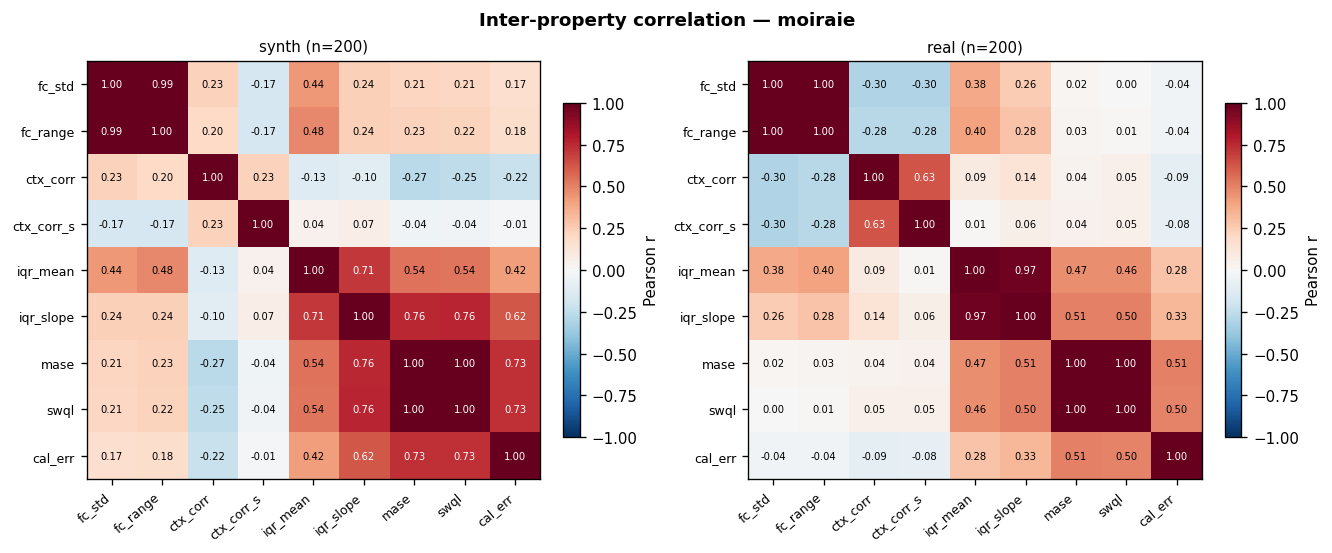

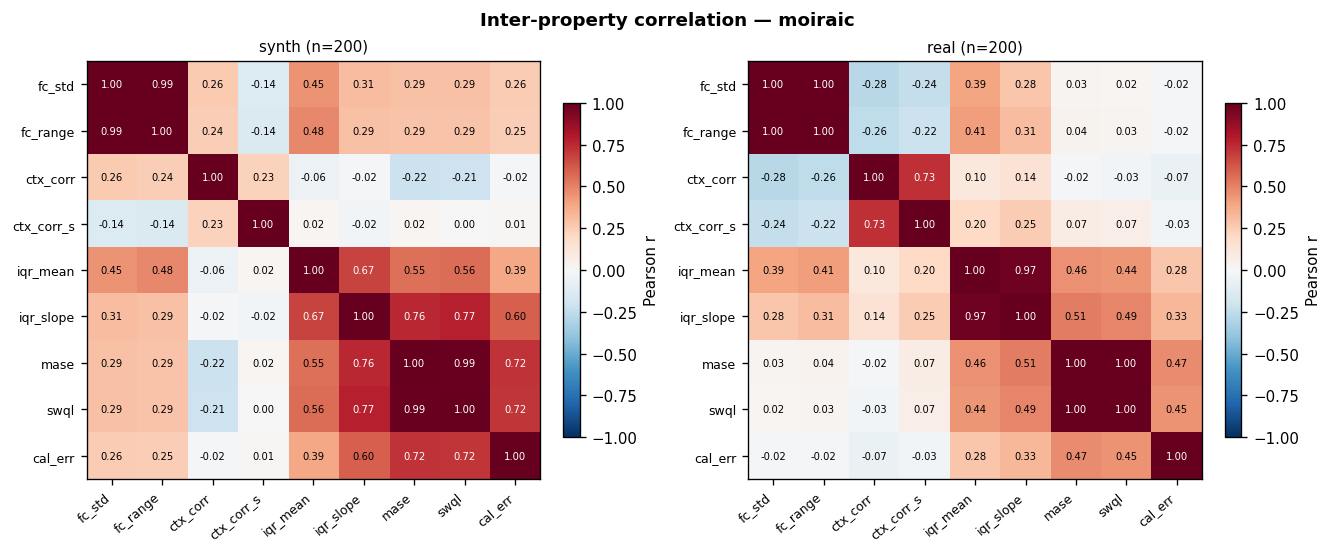

In [11]:
def prop_corr_matrix(
    props: dict[str, np.ndarray],
    keys: list[str],
) -> np.ndarray:
    """Compute pairwise Pearson correlation, handling NaN columns gracefully."""
    K = len(keys)
    C = np.full((K, K), np.nan)
    for i, ki in enumerate(keys):
        for j, kj in enumerate(keys):
            vi, vj = props[ki], props[kj]
            mask = np.isfinite(vi) & np.isfinite(vj)
            if mask.sum() > 2:
                C[i, j] = float(np.corrcoef(vi[mask], vj[mask])[0, 1])
    return C


short_labels = [
    'fc_std', 'fc_range', 'ctx_corr', 'ctx_corr_s',
    'iqr_mean', 'iqr_slope', 'mase', 'swql', 'cal_err',
]

for model_name in modules:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
    fig.suptitle(f'Inter-property correlation — {model_name}', fontsize=11, fontweight='bold')

    for ax, ds_name in zip(axes, ('synth', 'real')):
        C = prop_corr_matrix(properties[model_name][ds_name], PROP_KEYS)
        im = ax.imshow(C, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
        plt.colorbar(im, ax=ax, shrink=0.8, label='Pearson r')
        ax.set_xticks(range(len(PROP_KEYS)))
        ax.set_xticklabels(short_labels, rotation=40, ha='right', fontsize=7.5)
        ax.set_yticks(range(len(PROP_KEYS)))
        ax.set_yticklabels(short_labels, fontsize=7.5)
        ax.set_title(f'{ds_name} (n={len(properties[model_name][ds_name]["mase"])})',
                     fontsize=9)
        for i in range(len(PROP_KEYS)):
            for j in range(len(PROP_KEYS)):
                v = C[i, j]
                if not np.isnan(v):
                    ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                            fontsize=6, color='black' if abs(v) < 0.6 else 'white')

    plt.show()

---
## Section 6 — Summary statistics table

In [12]:
import pandas as pd

rows = []
for model_name in modules:
    for ds_name in ('synth', 'real'):
        props = properties[model_name][ds_name]
        for key in PROP_KEYS:
            vals = props[key]
            fin  = vals[np.isfinite(vals)]
            rows.append({
                'model':    model_name,
                'dataset':  ds_name,
                'property': key,
                'n_finite': int(len(fin)),
                'mean':     round(float(fin.mean()),   4) if len(fin) > 0 else np.nan,
                'std':      round(float(fin.std()),    4) if len(fin) > 0 else np.nan,
                'p10':      round(float(np.percentile(fin, 10)), 4) if len(fin) > 0 else np.nan,
                'median':   round(float(np.median(fin)), 4)  if len(fin) > 0 else np.nan,
                'p90':      round(float(np.percentile(fin, 90)), 4) if len(fin) > 0 else np.nan,
            })

df = pd.DataFrame(rows)
display(df.pivot_table(
    index=['property', 'dataset'],
    columns='model',
    values='median',
).round(4))

model                             moiraic  moiraie
property                 dataset                  
fc_ctx_corr              real     -0.3142  -0.3074
                         synth     0.0432   0.1198
fc_ctx_corr_seasonal     real     -0.2580  -0.3091
                         synth    -0.0155   0.0125
fc_iqr_mean              real     23.6557  21.2629
                         synth     2.5653   2.0903
fc_iqr_slope             real      0.0972   0.1047
                         synth     0.0041   0.0042
fc_range                 real      2.9072   3.0331
                         synth    -1.0371  -0.8081
fc_std                   real      1.6118   1.6824
                         synth    -2.5840  -2.4082
mase                     real      1.2829   1.2996
                         synth     0.8701   0.8558
quantile_calibration_err real      0.1297   0.1427
                         synth     0.0771   0.0759
swql                     real      0.5085   0.5058
                         synth     0.3376   0.3282